In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score


import sys
sys.path.insert(0, r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src")


In [ ]:
df = pd.read_parquet(r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\merged.parquet")


In [ ]:
print("Sulfonic acid positive:", df['sulfonic_acid'].sum())
print("Guanidino positive:", df['guanidino'].sum())
print("Total samples:", len(df))

Sulfonic acid positive: 77
Guanidino positive: 3145
Total samples: 191872


In [17]:
mask_rare = df['sulfonic_acid'] == 1
df_rare   = df[mask_rare]                                    # 68 samples
df_common = df[~mask_rare].sample(n=5000, random_state=42)  # 5000 samples
df_knn    = pd.concat([df_rare, df_common]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Guanidino in subset:", df_knn['guanidino'].sum())  # should be ~80 now
print("Sulfonic in subset: ", df_knn['sulfonic_acid'].sum())

X = np.stack(df_knn["transmittance"].values)
y = df_knn[["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"]].values

# Stratify on both rare classes by combining them into a single stratum key
strata = df_knn['sulfonic_acid'].astype(str) + df_knn['guanidino'].astype(str)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y[:, 2]  # stratify on sulfonic_acid
)

Guanidino in subset: 100
Sulfonic in subset:  77


Take a subset bc otherwise training takes too long

In [18]:
trf = StandardScaler()
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

# Wrap KNN in MultiOutputClassifier so one KNN per functional group
knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=20)) #try 20 neighbors first
knn.fit(X_train_trf, y_train)
y_pred = knn.predict(X_test_trf)


print("\nPer class results:")
print(classification_report(
    y_test, y_pred,
    target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
    zero_division=0
))


Per class results:
                 precision    recall  f1-score   support

carboxylic_acid       0.99      0.93      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.20      0.33        15
      guanidino       0.00      0.00      0.00        20

      micro avg       0.98      0.93      0.95      1052
      macro avg       0.74      0.53      0.57      1052
   weighted avg       0.96      0.93      0.94      1052
    samples avg       0.96      0.94      0.94      1052



Trying different k values  
Could look into finding optimal k?

In [19]:
# Trying different k values to see if it improves results
for k in [5, 10, 20, 50]:
    knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    
    print(f"\nk={k}")
    print(classification_report(
        y_test, y_pred,
        target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
        zero_division=0
    ))


k=5
                 precision    recall  f1-score   support

carboxylic_acid       0.98      0.94      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.60      0.75        15
      guanidino       0.80      0.40      0.53        20

      micro avg       0.97      0.94      0.96      1052
      macro avg       0.94      0.73      0.80      1052
   weighted avg       0.97      0.94      0.95      1052
    samples avg       0.96      0.94      0.95      1052


k=10
                 precision    recall  f1-score   support

carboxylic_acid       0.99      0.93      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.47      0.64        15
      guanidino       1.00      0.15      0.26        20

      micro avg       0.98      0.93      0.95      1052
      macro avg       0.99      0.63      0.71      1052
   weighted avg       0.98      0.93      0.95      1052
    samples avg

trying to find optimal k

In [20]:


# Define the parameter grid
param_grid = {'estimator__n_neighbors': range(1, 51)}  # Tests k=1 to 50

knn = MultiOutputClassifier(KNeighborsClassifier())

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1_weighted',   # Good for imbalanced multi-label data
    n_jobs=-1                # Use all CPU cores
)

grid_search.fit(X_train_trf, y_train)

best_k = grid_search.best_params_['estimator__n_neighbors']
print(f"Best k: {best_k}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred = grid_search.best_estimator_.predict(X_test_trf)
print(classification_report(
    y_test, y_pred,
    target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
    zero_division=0
))

Best k: 7
Best CV score: 0.9510
                 precision    recall  f1-score   support

carboxylic_acid       0.99      0.94      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.60      0.75        15
      guanidino       1.00      0.25      0.40        20

      micro avg       0.98      0.94      0.96      1052
      macro avg       0.99      0.69      0.77      1052
   weighted avg       0.98      0.94      0.95      1052
    samples avg       0.96      0.95      0.95      1052



C:\Users\20242732\AppData\Local\Temp\ipykernel_28360\370841400.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=15, ha='right')


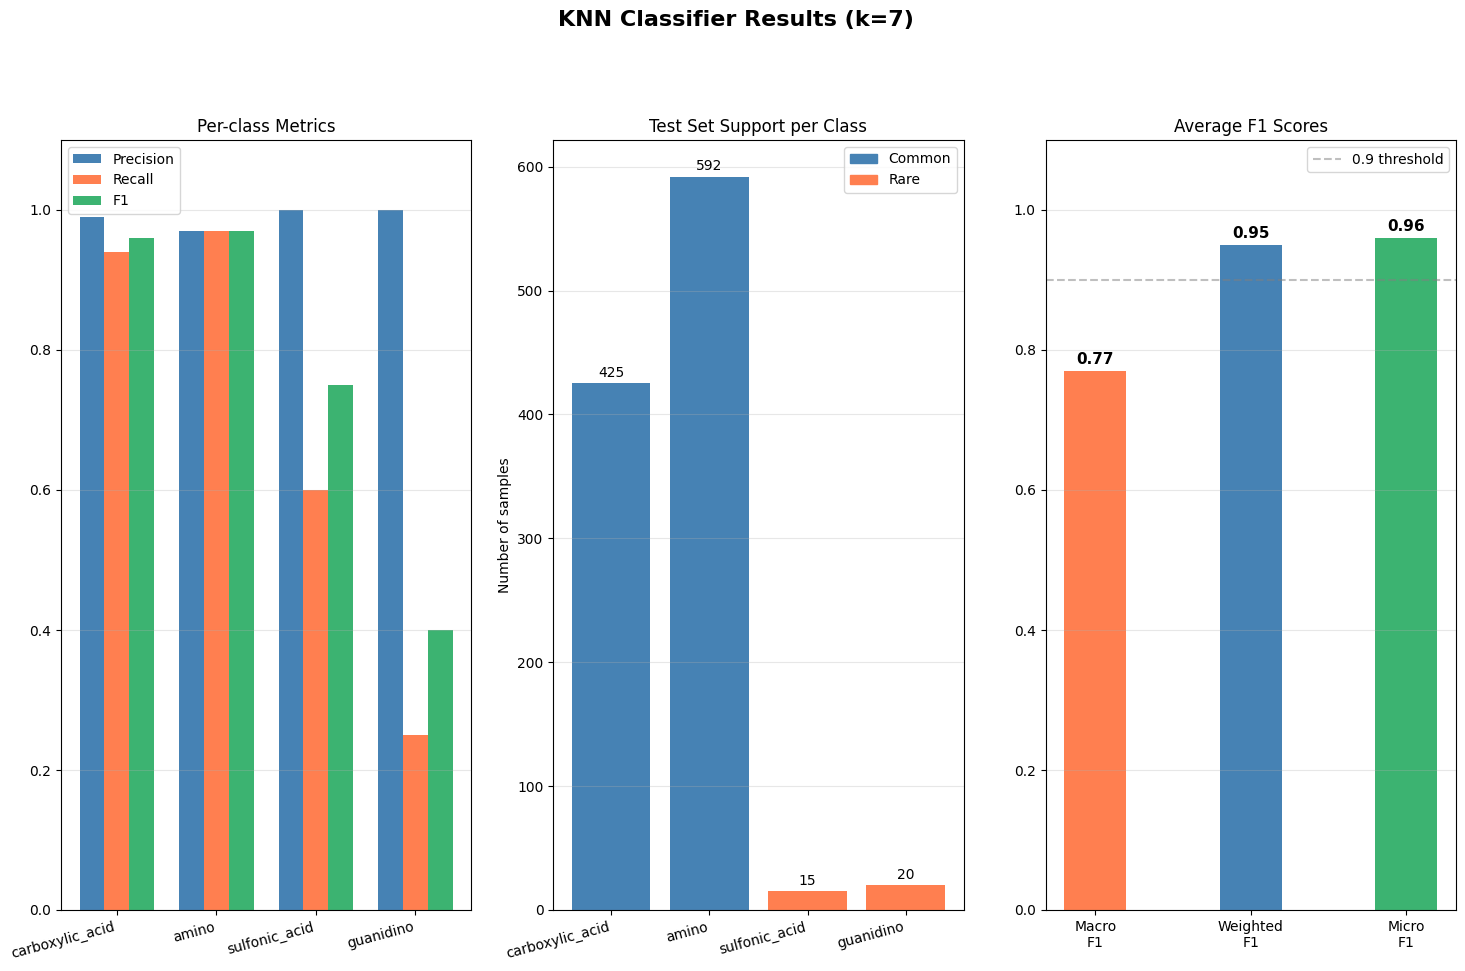

In [26]:
import matplotlib.patches as mpatches
import seaborn as sns

classes = ['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino']

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('KNN Classifier Results (k=7)', fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Per-class metrics bar chart ---
ax = axes[0]
precision = [0.99, 0.97, 1.00, 1.00]
recall    = [0.94, 0.97, 0.60, 0.25]
f1        = [0.96, 0.97, 0.75, 0.40]
x = np.arange(len(classes))
w = 0.25
ax.bar(x - w, precision, w, label='Precision', color='steelblue')
ax.bar(x,     recall,    w, label='Recall',    color='coral')
ax.bar(x + w, f1,        w, label='F1',        color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Support (class distribution in test set) ---
ax = axes[1]
support = [425, 592, 15, 20]
colors = ['steelblue', 'steelblue', 'coral', 'coral']
bars = ax.bar(classes, support, color=colors)
ax.set_title('Test Set Support per Class')
ax.set_xticklabels(classes, rotation=15, ha='right')
ax.set_ylabel('Number of samples')
for bar, val in zip(bars, support):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
common = mpatches.Patch(color='steelblue', label='Common')
rare   = mpatches.Patch(color='coral',     label='Rare')
ax.legend(handles=[common, rare])

# --- Plot 3: Macro vs Weighted F1 comparison ---
ax = axes[2]
avg_types = ['Macro\nF1', 'Weighted\nF1', 'Micro\nF1']
values = [0.77, 0.95, 0.96]
bar_colors = ['coral', 'steelblue', 'mediumseagreen']
bars = ax.bar(avg_types, values, color=bar_colors, width=0.4)
ax.set_ylim(0, 1.1)
ax.set_title('Average F1 Scores')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)


In [ ]:
# Train on everything
df_full = pd.read_parquet("merged.parquet")  # all MMS + Chemotion
X_full = np.stack(df_full["transmittance"].values)
y_full = df_full[["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"]].values

trf = StandardScaler()
X_full_scaled = trf.fit_transform(X_full)

knn_final = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=7))
knn_final.fit(X_full_scaled, y_full)

# Test on lab data
df_lab = pd.read_parquet("lab_data.parquet")
X_lab = np.stack(df_lab["transmittance"].values)
y_lab = df_lab[["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"]].values

X_lab_scaled = trf.transform(X_lab)  # use the same scaler, don't refit
y_pred_lab = knn_final.predict(X_lab_scaled)

print(classification_report(y_lab, y_pred_lab,
    target_names=["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"],
    zero_division=0))